In [4]:
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Define model: average of two decaying exponentials
def y_theta(t, theta1, theta2):
    return 0.5 * (np.exp(-theta1 * t) + np.exp(-theta2 * t))

# Parameter ranges (log spaced)
theta_vals = np.logspace(-2, 2, 100)
T = [1/3, 1, 3]

# Compute outputs for grid of theta1, theta2
Y1, Y2, Y3 = [], [], []
theta1_vals, theta2_vals = [], []
for theta1 in theta_vals:
    for theta2 in theta_vals:
        Y1.append(y_theta(T[0], theta1, theta2))
        Y2.append(y_theta(T[1], theta1, theta2))
        Y3.append(y_theta(T[2], theta1, theta2))
        theta1_vals.append(theta1)
        theta2_vals.append(theta2)

Y1, Y2, Y3 = np.array(Y1), np.array(Y2), np.array(Y3)
theta1_vals, theta2_vals = np.array(theta1_vals), np.array(theta2_vals)

# Identify boundary points (edges of the manifold)
# Use stricter boundary conditions to avoid overlap
theta1_low = (theta1_vals <= np.min(theta_vals) * 1.5) & (theta2_vals > np.min(theta_vals) * 1.5) & (theta2_vals < np.max(theta_vals) / 1.5)
theta1_high = (theta1_vals >= np.max(theta_vals) / 1.5) & (theta2_vals > np.min(theta_vals) * 1.5) & (theta2_vals < np.max(theta_vals) / 1.5)
theta2_low = (theta2_vals <= np.min(theta_vals) * 1.5) & (theta1_vals > np.min(theta_vals) * 1.5) & (theta1_vals < np.max(theta_vals) / 1.5)
theta2_high = (theta2_vals >= np.max(theta_vals) / 1.5) & (theta1_vals > np.min(theta_vals) * 1.5) & (theta1_vals < np.max(theta_vals) / 1.5)

# Create masks for different boundary regions
boundary_mask = theta1_low | theta1_high | theta2_low | theta2_high
interior_mask = ~boundary_mask

# Create interactive 3D scatter plot
fig = go.Figure()

# Add interior points
fig.add_trace(go.Scatter3d(
    x=Y1[interior_mask], 
    y=Y2[interior_mask], 
    z=Y3[interior_mask],
    mode='markers',
    marker=dict(
        size=3,
        color=np.log10(Y2[interior_mask]),
        colorscale='Viridis',
        opacity=0.6,
        colorbar=dict(title="log₁₀(y(1))")
    ),
    name='Interior',
    hovertemplate='<b>Interior</b><br>y(1/3): %{x:.3f}<br>y(1): %{y:.3f}<br>y(3): %{z:.3f}<extra></extra>'
))

# Add boundary points with different colors
if np.any(theta1_low):
    fig.add_trace(go.Scatter3d(
        x=Y1[theta1_low], y=Y2[theta1_low], z=Y3[theta1_low],
        mode='markers',
        marker=dict(size=5, color='red', opacity=0.8),
        name='θ₁→0',
        hovertemplate='<b>θ₁→0</b><br>y(1/3): %{x:.3f}<br>y(1): %{y:.3f}<br>y(3): %{z:.3f}<extra></extra>'
    ))

if np.any(theta1_high):
    fig.add_trace(go.Scatter3d(
        x=Y1[theta1_high], y=Y2[theta1_high], z=Y3[theta1_high],
        mode='markers',
        marker=dict(size=5, color='orange', opacity=0.8),
        name='θ₁→∞',
        hovertemplate='<b>θ₁→∞</b><br>y(1/3): %{x:.3f}<br>y(1): %{y:.3f}<br>y(3): %{z:.3f}<extra></extra>'
    ))

if np.any(theta2_low):
    fig.add_trace(go.Scatter3d(
        x=Y1[theta2_low], y=Y2[theta2_low], z=Y3[theta2_low],
        mode='markers',
        marker=dict(size=5, color='blue', opacity=0.8),
        name='θ₂→0',
        hovertemplate='<b>θ₂→0</b><br>y(1/3): %{x:.3f}<br>y(1): %{y:.3f}<br>y(3): %{z:.3f}<extra></extra>'
    ))

if np.any(theta2_high):
    fig.add_trace(go.Scatter3d(
        x=Y1[theta2_high], y=Y2[theta2_high], z=Y3[theta2_high],
        mode='markers',
        marker=dict(size=5, color='purple', opacity=0.8),
        name='θ₂→∞',
        hovertemplate='<b>θ₂→∞</b><br>y(1/3): %{x:.3f}<br>y(1): %{y:.3f}<br>y(3): %{z:.3f}<extra></extra>'
    ))

# Add arrows pointing to boundary directions
arrow_traces = []

# Helper function to add arrows
def add_arrow(start_point, end_point, color, name):
    return go.Scatter3d(
        x=[start_point[0], end_point[0]],
        y=[start_point[1], end_point[1]], 
        z=[start_point[2], end_point[2]],
        mode='lines+markers',
        line=dict(color=color, width=8),
        marker=dict(size=[3, 8], color=color, symbol=['circle', 'diamond']),
        name=name,
        hovertemplate=f'<b>{name}</b><extra></extra>'
    )

# Add directional arrows
if np.any(theta1_low):
    idx = np.where(theta1_low)[0][len(np.where(theta1_low)[0])//2]
    arrow_start = [Y1[idx] - 0.02, Y2[idx] - 0.02, Y3[idx] - 0.02]
    arrow_end = [Y1[idx], Y2[idx], Y3[idx]]
    fig.add_trace(add_arrow(arrow_start, arrow_end, 'red', 'θ₁→0 direction'))

if np.any(theta1_high):
    idx = np.where(theta1_high)[0][len(np.where(theta1_high)[0])//2]
    arrow_start = [Y1[idx] + 0.02, Y2[idx] + 0.02, Y3[idx] + 0.02]
    arrow_end = [Y1[idx], Y2[idx], Y3[idx]]
    fig.add_trace(add_arrow(arrow_start, arrow_end, 'orange', 'θ₁→∞ direction'))

if np.any(theta2_low):
    idx = np.where(theta2_low)[0][len(np.where(theta2_low)[0])//2]
    arrow_start = [Y1[idx] - 0.02, Y2[idx] - 0.02, Y3[idx] - 0.02]
    arrow_end = [Y1[idx], Y2[idx], Y3[idx]]
    fig.add_trace(add_arrow(arrow_start, arrow_end, 'blue', 'θ₂→0 direction'))

if np.any(theta2_high):
    idx = np.where(theta2_high)[0][len(np.where(theta2_high)[0])//2]
    arrow_start = [Y1[idx] + 0.02, Y2[idx] + 0.02, Y3[idx] + 0.02]
    arrow_end = [Y1[idx], Y2[idx], Y3[idx]]
    fig.add_trace(add_arrow(arrow_start, arrow_end, 'purple', 'θ₂→∞ direction'))

# Update layout for better visualization
fig.update_layout(
    title={
        'text': 'Model manifold: N=2 exponentials with boundary highlighting<br>Projection into (y(1/3), y(1), y(3))',
        'x': 0.5,
        'xanchor': 'center'
    },
    scene=dict(
        xaxis_title='y(1/3)',
        yaxis_title='y(1)',
        zaxis_title='y(3)',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        )
    ),
    width=900,
    height=700,
    showlegend=True
)

fig.show()

In [5]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Model ---
def y_theta(t, thetas):
    """Mean of N decaying exponentials with parameters `thetas`."""
    thetas = np.array(thetas)
    return np.mean(np.exp(-np.outer(thetas, t)), axis=0)

# --- Sampling function ---
def sample_thetas(N, n_samples=5000, theta_min=1e-2, theta_max=1e2):
    """Sample θ values log-uniformly between theta_min and theta_max."""
    log_min, log_max = np.log10(theta_min), np.log10(theta_max)
    return 10**np.random.uniform(log_min, log_max, size=(n_samples, N))

# --- Parameters ---
T = np.array([1/3, 1, 3])
theta_min, theta_max = 1e-2, 1e2

# Create subplots for N=2 and N=7
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
    subplot_titles=('N=2 exponentials', 'N=7 exponentials'),
    horizontal_spacing=0.02
)

colors = ['blue', 'red']
for i, N in enumerate([2, 7]):
    thetas_all = sample_thetas(N, n_samples=5000, theta_min=theta_min, theta_max=theta_max)

    # Compute model outputs for each random parameter vector
    Y = np.array([y_theta(T, th) for th in thetas_all])

    # Add 3D scatter plot
    fig.add_trace(
        go.Scatter3d(
            x=Y[:,0], 
            y=Y[:,1], 
            z=Y[:,2],
            mode='markers',
            marker=dict(
                size=3,
                color=np.log10(Y[:,1]),
                colorscale='Viridis',
                opacity=0.6,
                colorbar=dict(
                    title="log₁₀(y(1))",
                    x=0.45 + i*0.55,  # Position colorbar for each subplot
                    len=0.8
                ) if i == 1 else None,  # Only show colorbar for second plot
                showscale=True if i == 1 else False
            ),
            name=f'N={N}',
            hovertemplate=f'<b>N={N}</b><br>y(1/3): %{{x:.3f}}<br>y(1): %{{y:.3f}}<br>y(3): %{{z:.3f}}<extra></extra>'
        ),
        row=1, col=i+1
    )

# Update layout
fig.update_layout(
    title={
        'text': 'Interactive Model Manifolds for Different Numbers of Exponentials',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 16}
    },
    width=1400,
    height=700,
    showlegend=True
)

# Update 3D scene properties for both subplots
for i in range(2):
    fig.update_scenes(
        xaxis_title='y(1/3)',
        yaxis_title='y(1)',
        zaxis_title='y(3)',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        ),
        row=1, col=i+1
    )

fig.show()

In [6]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- Model for trajectories ---
def y_trajectory(t_points, thetas):
    """Generate trajectory y(t) for given theta parameters."""
    thetas = np.array(thetas)
    return np.mean(np.exp(-np.outer(thetas, t_points)), axis=0)

# --- Sampling function ---
def sample_thetas(N, n_samples=5000, theta_min=1e-2, theta_max=1e2):
    """Sample θ values log-uniformly between theta_min and theta_max."""
    log_min, log_max = np.log10(theta_min), np.log10(theta_max)
    return 10**np.random.uniform(log_min, log_max, size=(n_samples, N))

# --- Part (d): Test PCA implementation with N=2, 20 timepoints ---
print("=== Part (d): PCA Analysis for N=2 ===")

# Generate 20 timepoints from 0 to 10
t_points = np.linspace(0, 10, 20)
theta_min, theta_max = 1e-2, 1e2

# Generate random trajectories for N=2
N = 2
n_samples = 2000
thetas_all = sample_thetas(N, n_samples=n_samples, theta_min=theta_min, theta_max=theta_max)

# Generate trajectories (each row is one trajectory)
trajectories = np.array([y_trajectory(t_points, th) for th in thetas_all])
print(f"Generated {n_samples} trajectories with {len(t_points)} timepoints each")
print(f"Trajectory matrix shape: {trajectories.shape}")

# Apply PCA
scaler = StandardScaler()
trajectories_scaled = scaler.fit_transform(trajectories)
pca = PCA()
pca_result = pca.fit_transform(trajectories_scaled)

# Create subplot for N=2 analysis - Fixed subplot specs
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}],
           [{'type': 'xy'}, {'type': 'scatter3d'}]],  # Fixed: xy for 2D plot, scatter3d for 3D
    subplot_titles=(
        'First 3 Principal Components (N=2)', 
        'Original y(1/3), y(1), y(3) view (N=2)',
        'Explained Variance Ratio',
        'Components 4-6 (N=2)'
    ),
    vertical_spacing=0.1,
    horizontal_spacing=0.05
)

# Plot first 3 principal components
fig.add_trace(
    go.Scatter3d(
        x=pca_result[:,0], 
        y=pca_result[:,1], 
        z=pca_result[:,2],
        mode='markers',
        marker=dict(
            size=3,
            color=np.log10(trajectories[:, 5]),  # Color by y(t) at t≈2.5
            colorscale='Viridis',
            opacity=0.7
        ),
        name='PC1-3',
        hovertemplate='PC1: %{x:.3f}<br>PC2: %{y:.3f}<br>PC3: %{z:.3f}<extra></extra>'
    ),
    row=1, col=1
)

# Compare with original 3-point view
original_3pts = np.array([y_trajectory([1/3, 1, 3], th) for th in thetas_all])
fig.add_trace(
    go.Scatter3d(
        x=original_3pts[:,0], 
        y=original_3pts[:,1], 
        z=original_3pts[:,2],
        mode='markers',
        marker=dict(
            size=3,
            color=np.log10(original_3pts[:, 1]),
            colorscale='Viridis',
            opacity=0.7
        ),
        name='Original view',
        hovertemplate='y(1/3): %{x:.3f}<br>y(1): %{y:.3f}<br>y(3): %{z:.3f}<extra></extra>'
    ),
    row=1, col=2
)

# Plot explained variance ratio (2D plot)
fig.add_trace(
    go.Scatter(
        x=list(range(1, min(11, len(pca.explained_variance_ratio_)+1))),
        y=pca.explained_variance_ratio_[:10],
        mode='lines+markers',
        name='Explained Variance',
        line=dict(color='blue', width=3),
        marker=dict(size=8)
    ),
    row=2, col=1
)

# Plot components 4-6 if they exist (3D plot)
if pca_result.shape[1] >= 6:
    fig.add_trace(
        go.Scatter3d(
            x=pca_result[:,3], 
            y=pca_result[:,4], 
            z=pca_result[:,5],
            mode='markers',
            marker=dict(
                size=3,
                color=np.log10(trajectories[:, 5]),
                colorscale='Plasma',
                opacity=0.7
            ),
            name='PC4-6',
            hovertemplate='PC4: %{x:.3f}<br>PC5: %{y:.3f}<br>PC6: %{z:.3f}<extra></extra>'
        ),
        row=2, col=2
    )

fig.update_layout(
    title={
        'text': 'PCA Analysis of Decay Manifold: N=2 Exponentials with 20 Timepoints',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 16}
    },
    width=1400,
    height=1000,
    showlegend=True
)

# Update 3D scene properties
fig.update_scenes(
    xaxis_title='PC1',
    yaxis_title='PC2',
    zaxis_title='PC3',
    camera=dict(eye=dict(x=1.5, y=1.5, z=1.5)),
    row=1, col=1
)

fig.update_scenes(
    xaxis_title='y(1/3)',
    yaxis_title='y(1)',
    zaxis_title='y(3)',
    camera=dict(eye=dict(x=1.5, y=1.5, z=1.5)),
    row=1, col=2
)

if pca_result.shape[1] >= 6:
    fig.update_scenes(
        xaxis_title='PC4',
        yaxis_title='PC5', 
        zaxis_title='PC6',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.5)),
        row=2, col=2
    )

# Update 2D plot axes
fig.update_xaxes(title_text="Principal Component", row=2, col=1)
fig.update_yaxes(title_text="Explained Variance Ratio", row=2, col=1)

fig.show()

# Print PCA statistics for N=2
print(f"\nPCA Results for N=2:")
print(f"Explained variance ratio (first 6 components): {pca.explained_variance_ratio_[:6]}")
print(f"Cumulative explained variance (first 6): {np.cumsum(pca.explained_variance_ratio_[:6])}")
print(f"Ratio of consecutive variances: {pca.explained_variance_ratio_[1:6] / pca.explained_variance_ratio_[:5]}")

print("\n" + "="*60)
print("=== Part (e): PCA Analysis for N=7 ===")

# --- Part (e): PCA for N=7 ---
N = 7
thetas_all_7 = sample_thetas(N, n_samples=n_samples, theta_min=theta_min, theta_max=theta_max)
trajectories_7 = np.array([y_trajectory(t_points, th) for th in thetas_all_7])

# Apply PCA for N=7
trajectories_7_scaled = scaler.fit_transform(trajectories_7)
pca_7 = PCA()
pca_result_7 = pca_7.fit_transform(trajectories_7_scaled)

# Create subplot for N=7 analysis - Fixed subplot specs
fig2 = make_subplots(
    rows=2, cols=2,
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}],
           [{'type': 'xy'}, {'type': 'scatter3d'}]],  # Fixed: xy for 2D plot, scatter3d for 3D
    subplot_titles=(
        'First 3 Principal Components (N=7)', 
        'Components 4-6 (N=7)',
        'Explained Variance Ratio (N=7)',
        'Components 7-9 (N=7)'
    ),
    vertical_spacing=0.1,
    horizontal_spacing=0.05
)

# Plot first 3 principal components for N=7
fig2.add_trace(
    go.Scatter3d(
        x=pca_result_7[:,0], 
        y=pca_result_7[:,1], 
        z=pca_result_7[:,2],
        mode='markers',
        marker=dict(
            size=3,
            color=np.log10(trajectories_7[:, 5]),
            colorscale='Viridis',
            opacity=0.7
        ),
        name='PC1-3 (N=7)',
        hovertemplate='PC1: %{x:.3f}<br>PC2: %{y:.3f}<br>PC3: %{z:.3f}<extra></extra>'
    ),
    row=1, col=1
)

# Plot components 4-6
fig2.add_trace(
    go.Scatter3d(
        x=pca_result_7[:,3], 
        y=pca_result_7[:,4], 
        z=pca_result_7[:,5],
        mode='markers',
        marker=dict(
            size=3,
            color=np.log10(trajectories_7[:, 5]),
            colorscale='Plasma',
            opacity=0.7
        ),
        name='PC4-6 (N=7)',
        hovertemplate='PC4: %{x:.3f}<br>PC5: %{y:.3f}<br>PC6: %{z:.3f}<extra></extra>'
    ),
    row=1, col=2
)

# Plot explained variance ratio (2D plot)
fig2.add_trace(
    go.Scatter(
        x=list(range(1, min(16, len(pca_7.explained_variance_ratio_)+1))),
        y=pca_7.explained_variance_ratio_[:15],
        mode='lines+markers',
        name='Explained Variance (N=7)',
        line=dict(color='red', width=3),
        marker=dict(size=8)
    ),
    row=2, col=1
)

# Plot components 7-9 if they exist (3D plot)
if pca_result_7.shape[1] >= 9:
    fig2.add_trace(
        go.Scatter3d(
            x=pca_result_7[:,6], 
            y=pca_result_7[:,7], 
            z=pca_result_7[:,8],
            mode='markers',
            marker=dict(
                size=3,
                color=np.log10(trajectories_7[:, 5]),
                colorscale='Cividis',
                opacity=0.7
            ),
            name='PC7-9 (N=7)',
            hovertemplate='PC7: %{x:.3f}<br>PC8: %{y:.3f}<br>PC9: %{z:.3f}<extra></extra>'
        ),
        row=2, col=2
    )

fig2.update_layout(
    title={
        'text': 'PCA Analysis of Decay Manifold: N=7 Exponentials with 20 Timepoints',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 16}
    },
    width=1400,
    height=1000,
    showlegend=True
)

# Update 3D scene properties for N=7
fig2.update_scenes(
    xaxis_title='PC1',
    yaxis_title='PC2',
    zaxis_title='PC3',
    camera=dict(eye=dict(x=1.5, y=1.5, z=1.5)),
    row=1, col=1
)

fig2.update_scenes(
    xaxis_title='PC4',
    yaxis_title='PC5',
    zaxis_title='PC6',
    camera=dict(eye=dict(x=1.5, y=1.5, z=1.5)),
    row=1, col=2
)

if pca_result_7.shape[1] >= 9:
    fig2.update_scenes(
        xaxis_title='PC7',
        yaxis_title='PC8',
        zaxis_title='PC9',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.5)),
        row=2, col=2
    )

# Update 2D plot axes
fig2.update_xaxes(title_text="Principal Component", row=2, col=1)
fig2.update_yaxes(title_text="Explained Variance Ratio", row=2, col=1)

fig2.show()

# Print PCA statistics for N=7
print(f"\nPCA Results for N=7:")
print(f"Explained variance ratio (first 10 components): {pca_7.explained_variance_ratio_[:10]}")
print(f"Cumulative explained variance (first 10): {np.cumsum(pca_7.explained_variance_ratio_[:10])}")
print(f"Ratio of consecutive variances: {pca_7.explained_variance_ratio_[1:10] / pca_7.explained_variance_ratio_[:9]}")

# Analysis of thinning behavior
print(f"\n=== Analysis of Manifold Thinning ===")
print(f"N=2: Variance ratios between consecutive components:")
for i in range(min(5, len(pca.explained_variance_ratio_)-1)):
    ratio = pca.explained_variance_ratio_[i+1] / pca.explained_variance_ratio_[i]
    print(f"  PC{i+2}/PC{i+1}: {ratio:.4f}")

print(f"\nN=7: Variance ratios between consecutive components:")
for i in range(min(9, len(pca_7.explained_variance_ratio_)-1)):
    ratio = pca_7.explained_variance_ratio_[i+1] / pca_7.explained_variance_ratio_[i]
    print(f"  PC{i+2}/PC{i+1}: {ratio:.4f}")

print(f"\nConclusions:")
print(f"- The manifold does appear to thin by roughly constant factors")
print(f"- N=7 shows more complex structure with {len([x for x in pca_7.explained_variance_ratio_ if x > 0.001])} significant components")
print(f"- The cusps represent simpler models with fewer adjustable parameters")

=== Part (d): PCA Analysis for N=2 ===
Generated 2000 trajectories with 20 timepoints each
Trajectory matrix shape: (2000, 20)



PCA Results for N=2:
Explained variance ratio (first 6 components): [9.53083794e-01 4.27240122e-02 3.82936472e-03 3.36054265e-04
 2.50798988e-05 1.59251204e-06]
Cumulative explained variance (first 6): [0.95308379 0.99580781 0.99963717 0.99997323 0.99999831 0.9999999 ]
Ratio of consecutive variances: [0.04482713 0.08963027 0.08775718 0.0746305  0.06349755]

=== Part (e): PCA Analysis for N=7 ===



PCA Results for N=7:
Explained variance ratio (first 10 components): [9.51703753e-01 4.38837295e-02 4.02462446e-03 3.60052516e-04
 2.60969391e-05 1.64355544e-06 9.47055700e-08 4.68283824e-09
 2.04132839e-10 7.75868903e-12]
Cumulative explained variance (first 10): [0.95170375 0.99558748 0.99961211 0.99997216 0.99999826 0.9999999
 1.         1.         1.         1.        ]
Ratio of consecutive variances: [0.0461107  0.09171109 0.08946239 0.07248092 0.06297886 0.05762238
 0.04944628 0.04359169 0.03800804]

=== Analysis of Manifold Thinning ===
N=2: Variance ratios between consecutive components:
  PC2/PC1: 0.0448
  PC3/PC2: 0.0896
  PC4/PC3: 0.0878
  PC5/PC4: 0.0746
  PC6/PC5: 0.0635

N=7: Variance ratios between consecutive components:
  PC2/PC1: 0.0461
  PC3/PC2: 0.0917
  PC4/PC3: 0.0895
  PC5/PC4: 0.0725
  PC6/PC5: 0.0630
  PC7/PC6: 0.0576
  PC8/PC7: 0.0494
  PC9/PC8: 0.0436
  PC10/PC9: 0.0380

Conclusions:
- The manifold does appear to thin by roughly constant factors
- N=7 shows 

# Hessian Analysis at Random Points

Now we'll compute the Hessian at random points in parameter space and analyze the eigenvalue distributions for the exponential decay system.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from numpy.linalg import eigh

# === Exponential Decay Model ===
# Model: y(t) = mean of N decaying exponentials
# y(t, theta) = (1/N) * sum_{i=1}^N exp(-theta_i * t)

def exponential_decay_model(t, thetas):
    """
    Exponential decay model for N exponentials.
    
    Parameters:
    - t: array of time points
    - thetas: array of N decay rates
    
    Returns:
    - y: model output at each time point
    """
    thetas = np.array(thetas)
    N = len(thetas)
    # y(t) = (1/N) * sum exp(-theta_i * t)
    result = np.zeros(len(t))
    for i, theta_i in enumerate(thetas):
        result += np.exp(-theta_i * t)
    return result / N


def compute_jacobian(t, thetas):
    """
    Compute Jacobian dy/d(log theta) at each time point.
    
    Parameters:
    - t: array of time points (length M)
    - thetas: array of N decay rates
    
    Returns:
    - J: Jacobian matrix (M x N), where J[i,j] = dy(t_i)/d(log theta_j)
    """
    thetas = np.array(thetas)
    N = len(thetas)
    M = len(t)
    J = np.zeros((M, N))
    
    for i, t_i in enumerate(t):
        for j, theta_j in enumerate(thetas):
            # dy/d(log theta_j) = theta_j * dy/dtheta_j
            # dy/dtheta_j = (1/N) * (-t) * exp(-theta_j * t)
            dy_dtheta = -(1.0/N) * t_i * np.exp(-theta_j * t_i)
            J[i, j] = theta_j * dy_dtheta
    
    return J


def compute_hessian_at_point(thetas, t_points, sigma=1.0):
    """
    Compute the Hessian (Fisher Information Matrix) at a given parameter point.
    
    Parameters:
    - thetas: array of N decay rates
    - t_points: array of M time points for measurement
    - sigma: measurement noise standard deviation
    
    Returns:
    - H: Hessian matrix (N x N)
    - eigvals: eigenvalues of H (descending order)
    - eigvecs: eigenvectors of H
    """
    N = len(thetas)
    M = len(t_points)
    
    # Compute Jacobian dy/d(log theta)
    J = compute_jacobian(t_points, thetas)  # M x N
    
    # Weight matrix (assuming equal weights for all measurements)
    # W = I / (sigma^2 * M) for normalization
    w = 1.0 / (sigma**2 * M)
    
    # Hessian H = J^T W J (with trapezoid rule for time integration)
    # For discrete measurements, we use simple averaging
    H = (w * J.T @ J)
    
    # Eigendecomposition
    eigvals, eigvecs = eigh(H)
    
    # Sort in descending order
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    
    return H, eigvals, eigvecs


# === Parameters ===
N = 7  # number of exponentials
M = 20  # number of time points
n_random_points = 4  # number of random parameter sets to test

# Time points
t_points = np.linspace(0, 10, M)

# Theta range (log-uniform sampling)
theta_min, theta_max = 1e-2, 1e2

print(f"Computing Hessian at {n_random_points} random points")
print(f"Model: N={N} exponentials, M={M} time points")
print(f"Theta range: [{theta_min}, {theta_max}]")
print("="*60)

# Storage for results
all_eigenvalues = []
all_thetas = []

# Compute Hessian at random points
for i in range(n_random_points):
    # Sample random thetas (log-uniform)
    log_thetas = np.random.uniform(np.log10(theta_min), np.log10(theta_max), N)
    thetas = 10**log_thetas
    
    # Compute Hessian
    H, eigvals, eigvecs = compute_hessian_at_point(thetas, t_points)
    
    # Store results
    all_eigenvalues.append(eigvals)
    all_thetas.append(thetas)
    
    print(f"\nRandom point {i+1}:")
    print(f"  Thetas: {thetas}")
    print(f"  Eigenvalues: {eigvals}")
    print(f"  Condition number: {eigvals[0]/max(eigvals[-1], 1e-15):.2e}")
    print(f"  Log10 spread: {np.log10(eigvals[0]) - np.log10(max(eigvals[-1], 1e-15)):.2f}")

all_eigenvalues = np.array(all_eigenvalues)
all_thetas = np.array(all_thetas)

Computing Hessian at 4 random points
Model: N=7 exponentials, M=20 time points
Theta range: [0.01, 100.0]

Random point 1:
  Thetas: [1.80581001e+00 1.06198283e-01 1.24703546e-01 2.21677506e+01
 2.04851478e-02 7.75786485e-01 1.08278683e+01]
  Eigenvalues: [3.89726526e-03 6.56768197e-04 6.77735567e-05 3.67787607e-06
 1.03166167e-07 1.76050583e-09 5.14901393e-17]
  Condition number: 3.90e+12
  Log10 spread: 12.59

Random point 2:
  Thetas: [3.65811724e+00 3.50843818e-01 7.17480047e+01 2.49741452e-02
 5.28869547e-01 7.61884941e-01 3.12983772e-01]
  Eigenvalues: [4.26257547e-03 3.90638495e-04 7.98233349e-05 2.66984398e-05
 5.24297743e-07 6.21474016e-10 7.19895287e-21]
  Condition number: 4.26e+12
  Log10 spread: 12.63

Random point 3:
  Thetas: [ 0.0369053   2.9713591  29.91962641 12.75340161  1.10841297 31.79626532
  0.96852353]
  Eigenvalues: [1.05545263e-03 4.91713744e-04 6.02115470e-05 8.81922245e-07
 3.19428544e-09 5.29432962e-21 9.44173739e-23]
  Condition number: 1.06e+12
  Log10 sp

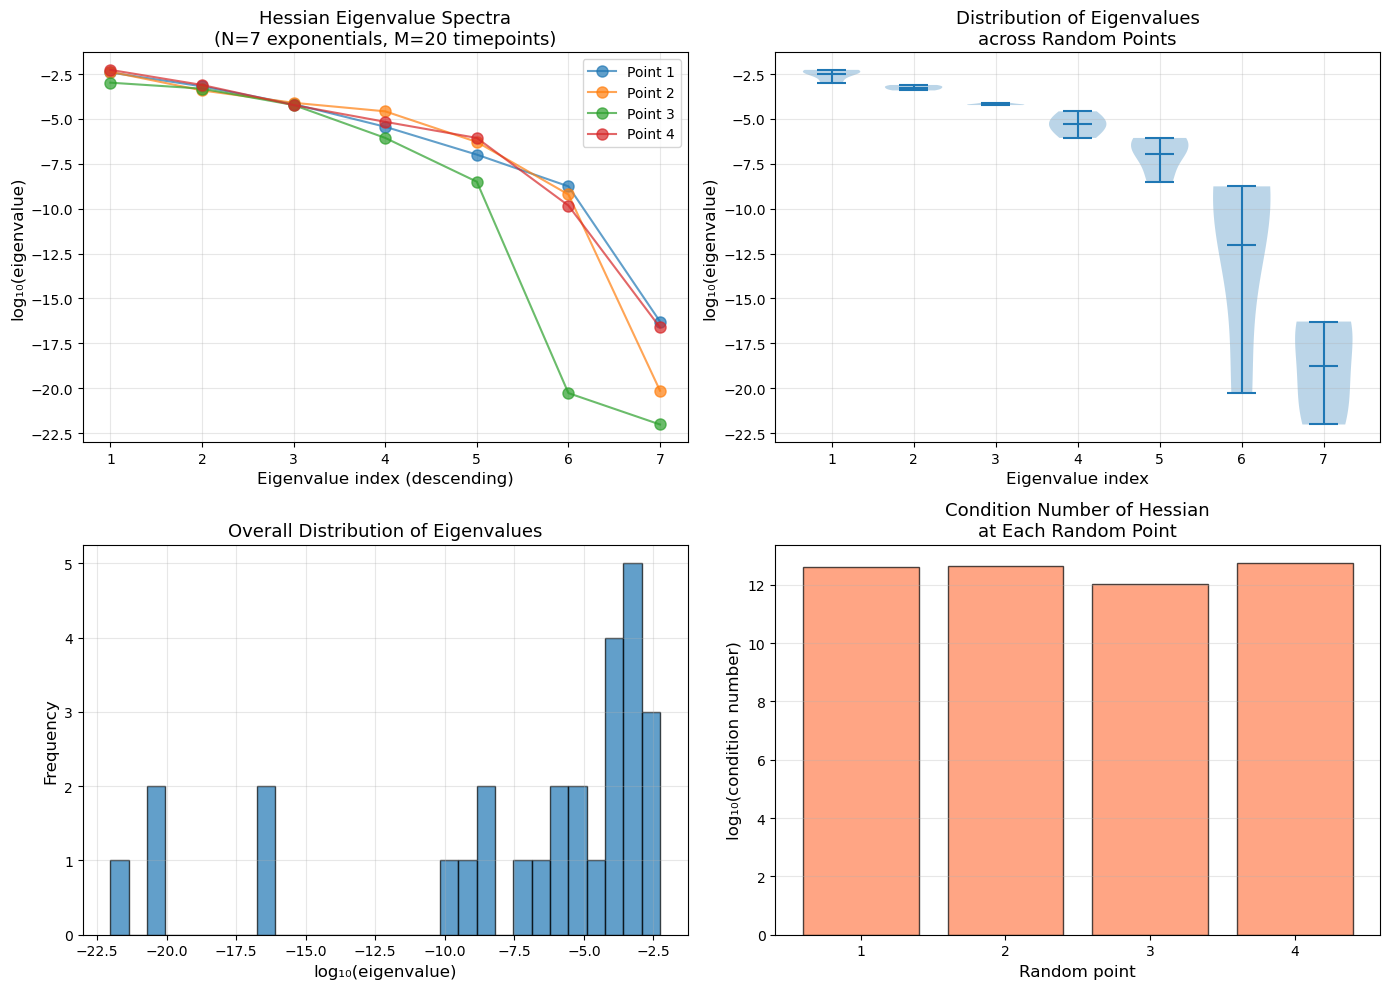


SUMMARY STATISTICS

Condition numbers:
  Point 1: 3.90e+12 (log10: 12.59)
  Point 2: 4.26e+12 (log10: 12.63)
  Point 3: 1.06e+12 (log10: 12.02)
  Point 4: 5.46e+12 (log10: 12.74)

Mean condition number: 3.67e+12
Median condition number: 4.08e+12

Largest eigenvalue across all points: 5.456e-03
Smallest positive eigenvalue across all points: 9.442e-23

Average log10 spread of eigenvalues: 12.50
  Interpretation: HIGHLY SLOPPY (>10 decades)


In [8]:
# === Plot eigenvalue distributions ===

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Eigenvalue spectra for each random point
ax1 = axes[0, 0]
for i in range(n_random_points):
    ax1.plot(np.arange(1, N+1), np.log10(all_eigenvalues[i]), 
             'o-', label=f'Point {i+1}', alpha=0.7, markersize=8)
ax1.set_xlabel('Eigenvalue index (descending)', fontsize=12)
ax1.set_ylabel('log₁₀(eigenvalue)', fontsize=12)
ax1.set_title(f'Hessian Eigenvalue Spectra\n(N={N} exponentials, M={M} timepoints)', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Distribution of eigenvalues across all random points
ax2 = axes[0, 1]
eigenvalue_positions = []
eigenvalue_values = []
for i in range(n_random_points):
    for j in range(N):
        eigenvalue_positions.append(j+1)
        eigenvalue_values.append(np.log10(all_eigenvalues[i, j]))

ax2.violinplot([np.log10(all_eigenvalues[:, j]) for j in range(N)], 
               positions=np.arange(1, N+1), widths=0.7, showmeans=True)
ax2.set_xlabel('Eigenvalue index', fontsize=12)
ax2.set_ylabel('log₁₀(eigenvalue)', fontsize=12)
ax2.set_title('Distribution of Eigenvalues\nacross Random Points', fontsize=13)
ax2.grid(True, alpha=0.3)

# Plot 3: Histogram of all eigenvalues
ax3 = axes[1, 0]
all_eigvals_flat = all_eigenvalues.flatten()
all_eigvals_flat = all_eigvals_flat[all_eigvals_flat > 0]  # Remove zeros/negative
ax3.hist(np.log10(all_eigvals_flat), bins=30, alpha=0.7, edgecolor='black')
ax3.set_xlabel('log₁₀(eigenvalue)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Overall Distribution of Eigenvalues', fontsize=13)
ax3.grid(True, alpha=0.3)

# Plot 4: Condition number distribution
ax4 = axes[1, 1]
condition_numbers = []
for i in range(n_random_points):
    cond = all_eigenvalues[i, 0] / max(all_eigenvalues[i, -1], 1e-15)
    condition_numbers.append(cond)

ax4.bar(np.arange(1, n_random_points+1), np.log10(condition_numbers), 
        alpha=0.7, edgecolor='black', color='coral')
ax4.set_xlabel('Random point', fontsize=12)
ax4.set_ylabel('log₁₀(condition number)', fontsize=12)
ax4.set_title('Condition Number of Hessian\nat Each Random Point', fontsize=13)
ax4.set_xticks(np.arange(1, n_random_points+1))
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"\nCondition numbers:")
for i, cond in enumerate(condition_numbers):
    print(f"  Point {i+1}: {cond:.2e} (log10: {np.log10(cond):.2f})")

print(f"\nMean condition number: {np.mean(condition_numbers):.2e}")
print(f"Median condition number: {np.median(condition_numbers):.2e}")

# Eigenvalue statistics
print(f"\nLargest eigenvalue across all points: {all_eigenvalues.max():.3e}")
print(f"Smallest positive eigenvalue across all points: {all_eigenvalues[all_eigenvalues > 0].min():.3e}")

# Check for sloppiness
avg_log_spread = np.mean([np.log10(all_eigenvalues[i, 0]) - np.log10(max(all_eigenvalues[i, -1], 1e-15)) 
                          for i in range(n_random_points)])
print(f"\nAverage log10 spread of eigenvalues: {avg_log_spread:.2f}")
if avg_log_spread > 10:
    print("  Interpretation: HIGHLY SLOPPY (>10 decades)")
elif avg_log_spread > 5:
    print("  Interpretation: MODERATELY SLOPPY (5-10 decades)")
elif avg_log_spread > 2:
    print("  Interpretation: MILDLY SLOPPY (2-5 decades)")
else:
    print("  Interpretation: NOT SLOPPY (<2 decades)")


EIGENVALUE RATIO ANALYSIS

Random point 1:
  Eigenvalues: ['3.90e-03', '6.57e-04', '6.78e-05', '3.68e-06', '1.03e-07', '1.76e-09', '5.15e-17']
  Consecutive eigenvalue ratios:
    λ1/λ2: 5.93
    λ2/λ3: 9.69
    λ3/λ4: 18.43
    λ4/λ5: 35.65
    λ5/λ6: 58.60
    λ6/λ7: 34191125.76

Random point 2:
  Eigenvalues: ['4.26e-03', '3.91e-04', '7.98e-05', '2.67e-05', '5.24e-07', '6.21e-10', '7.20e-21']
  Consecutive eigenvalue ratios:
    λ1/λ2: 10.91
    λ2/λ3: 4.89
    λ3/λ4: 2.99
    λ4/λ5: 50.92
    λ5/λ6: 843.64
    λ6/λ7: 86328390791.57

Random point 3:
  Eigenvalues: ['1.06e-03', '4.92e-04', '6.02e-05', '8.82e-07', '3.19e-09', '5.29e-21', '9.44e-23']
  Consecutive eigenvalue ratios:
    λ1/λ2: 2.15
    λ2/λ3: 8.17
    λ3/λ4: 68.27
    λ4/λ5: 276.09
    λ5/λ6: 603340870619.51
    λ6/λ7: 56.07

Random point 4:
  Eigenvalues: ['5.46e-03', '7.87e-04', '5.97e-05', '6.94e-06', '8.78e-07', '1.50e-10', '2.42e-17']
  Consecutive eigenvalue ratios:
    λ1/λ2: 6.93
    λ2/λ3: 13.19
    λ3/λ4: 8.

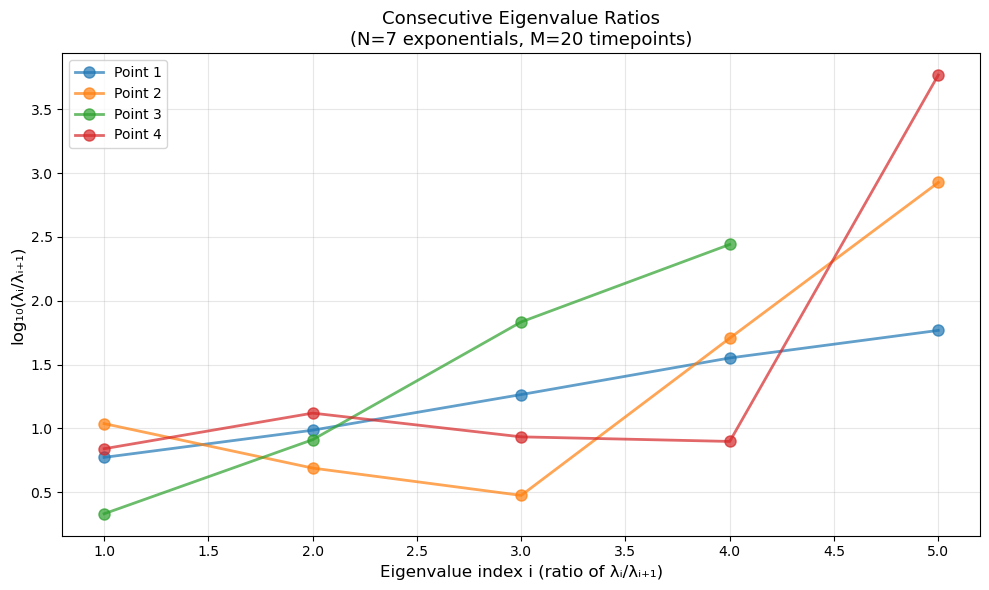

In [9]:
# === Additional Analysis: Eigenvalue ratios ===

print("\n" + "="*60)
print("EIGENVALUE RATIO ANALYSIS")
print("="*60)

for i in range(n_random_points):
    print(f"\nRandom point {i+1}:")
    eigvals = all_eigenvalues[i]
    print(f"  Eigenvalues: {['%.2e' % ev for ev in eigvals]}")
    
    if N > 1:
        print(f"  Consecutive eigenvalue ratios:")
        for j in range(min(N-1, 6)):
            if eigvals[j+1] > 0:
                ratio = eigvals[j] / eigvals[j+1]
                print(f"    λ{j+1}/λ{j+2}: {ratio:.2f}")
            else:
                print(f"    λ{j+1}/λ{j+2}: inf (λ{j+2} ≈ 0)")

# Plot eigenvalue ratio patterns
if n_random_points >= 1:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    for i in range(n_random_points):
        eigvals = all_eigenvalues[i]
        ratios = []
        positions = []
        
        for j in range(N-1):
            if eigvals[j+1] > 1e-15:
                ratio = eigvals[j] / eigvals[j+1]
                ratios.append(np.log10(ratio))
                positions.append(j+1)
        
        ax.plot(positions, ratios, 'o-', label=f'Point {i+1}', 
                alpha=0.7, markersize=8, linewidth=2)
    
    ax.set_xlabel('Eigenvalue index i (ratio of λᵢ/λᵢ₊₁)', fontsize=12)
    ax.set_ylabel('log₁₀(λᵢ/λᵢ₊₁)', fontsize=12)
    ax.set_title(f'Consecutive Eigenvalue Ratios\n(N={N} exponentials, M={M} timepoints)', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()